# 🍕 **Project: Zomato Restaurant Price & Rating Prediction**



## 📊 **Phase 1: Project Overview & Libraries Setup**

### 🎯 **Objective:**
Is project ka main goal hai Zomato ke restaurant dataset ko analyze karna aur ek Machine Learning Regression Model banana jo restaurant ke features (jaise: Location, Cuisines, Online Order facility, Aur Book Table option) ke hisab se wahan ka **Approximate Cost for 2 People** (do logon ke khane ka kharcha) predict kar sake.


### 🛠️ **Step 1: Importing Core Data Science Libraries**
Sabse pehle hum data manipulation aur mathematical calculation ke liye core libraries (**Pandas, NumPy**) aur advanced visualization ke liye Matplotlib aur Seaborn ko import karenge.

In [1]:
# Importing standard libraries for data science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up style for beautiful plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Saari core libraries successfully import ho gayi hain!")

✅ Saari core libraries successfully import ho gayi hain!


### 📂 **Phase 1.2: Mock Zomato Dataset Creation**
Real-world data cleaning aur handling seekhne ke liye, hum ek simulated Zomato dataset taiyar kar rahe hain. Is dataset mein restaurants ke naam, cuisines, online order availability, rating, aur hamara target variable 'approx_cost' (cost for 2 people) shamil hoga. Hum jaanbujhkar isme kuch missing values aur garbad entries bhi dalenge taaki hum aage unhe clean karna seekh sakein!

In [2]:
# Creating a realistic simulated Zomato dataset
raw_zomato_data = {
    'restaurant_name': [
        'Spice Court', 'The Pizza Corner', 'Cafe Coffee Day', 'Chai Point',
        'Burger King', 'Punjab Grill', 'Barbeque Nation', 'Sagar Ratna',
        'Social', 'Empire Restaurant', 'Toscano', 'Udupi Upahar'
    ],
    'online_order': ['Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes'],
    'book_table': ['No', 'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No'],
    'rate': ['3.8/5', '4.2/5', '3.5/5', 'NEW', '4.0/5', '4.5/5', '4.7/5', '3.9/5', '4.3/5', '4.1/5', '-', '3.6/5'],
    'votes': [120, 450, 80, 0, 850, 1200, 2300, 310, 1800, 920, 0, 150],
    'location': ['Koramangala', 'Indiranagar', 'Koramangala', 'Whitefield', 'Jayanagar', 'MG Road', 'Indiranagar', 'Jayanagar', 'Koramangala', 'Indiranagar', 'Whitefield', 'Koramangala'],
    'cuisines': ['North Indian', 'Pizza, Fast Food', 'Cafe', 'Beverages', 'Fast Food, Burgers', 'North Indian, Mughlai', 'North Indian, BBQ', 'South Indian', 'North Indian, Continental', 'North Indian, Biryani', 'Italian', 'South Indian'],
    'approx_cost(for 2 people)': ['600', '500', '400', '250', '450', '1,800', '2,100', '400', '1,500', '800', '1,200', '200']
}

# Converting into a Pandas DataFrame
df = pd.DataFrame(raw_zomato_data)

# Visualizing the first 5 rows
print("--- Zomato Raw Dataset Successfully Created! ---")
print(df.head())

--- Zomato Raw Dataset Successfully Created! ---
    restaurant_name online_order book_table   rate  votes     location  \
0       Spice Court          Yes         No  3.8/5    120  Koramangala   
1  The Pizza Corner          Yes         No  4.2/5    450  Indiranagar   
2   Cafe Coffee Day           No         No  3.5/5     80  Koramangala   
3        Chai Point          Yes         No    NEW      0   Whitefield   
4       Burger King          Yes         No  4.0/5    850    Jayanagar   

             cuisines approx_cost(for 2 people)  
0        North Indian                       600  
1    Pizza, Fast Food                       500  
2                Cafe                       400  
3           Beverages                       250  
4  Fast Food, Burgers                       450  


## 🧹 **Phase 2: Data Cleaning & Transformation**
Asli duniya ka data hamesha 'dirty' hota hai. Hamare dataset mein do bade challenges hain:
1. **Invalid Ratings:** 'NEW' aur '-' jaise entries ko handle karna hoga (hum inhe 0 ya NaN mein badlenge).
2. **Data Type Conversion:** 'approx_cost' ek string/text hai (comma hone ki wajah se). Machine learning model ke liye humein ise 'Integer' (number) mein badalna padega.

In [3]:
# 1. 'approx_cost' mein se comma (,) hatana aur use number (integer) banana
df['approx_cost(for 2 people)'] = df['approx_cost(for 2 people)'].str.replace(',', '').astype(int)

# 2. 'rate' column ko clean karna (sirf numeric value rakhna)
# 'NEW' aur '-' ko 0 bana rahe hain
df['rate'] = df['rate'].replace(['NEW', '-'], '0/5')
df['rate'] = df['rate'].apply(lambda x: float(x.split('/')[0]))

# Check ki data sahi hua ya nahi
print("--- Cleaned Data Info ---")
print(df.info())
print("\n--- Sample of Cleaned Data ---")
print(df.head())

--- Cleaned Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   restaurant_name            12 non-null     object 
 1   online_order               12 non-null     object 
 2   book_table                 12 non-null     object 
 3   rate                       12 non-null     float64
 4   votes                      12 non-null     int64  
 5   location                   12 non-null     object 
 6   cuisines                   12 non-null     object 
 7   approx_cost(for 2 people)  12 non-null     int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 900.0+ bytes
None

--- Sample of Cleaned Data ---
    restaurant_name online_order book_table  rate  votes     location  \
0       Spice Court          Yes         No   3.8    120  Koramangala   
1  The Pizza Corner          Yes         No   4.2    450  Indi

## 📊 **Phase 3: Exploratory Data Analysis (EDA)**
Data clean hone ke baad, ab hum graphs aur charts ke zariye do bade sawalon ke jawab dhoondenge:
1. **Location vs Cost:** Kis area/location mein sabse mehange restaurants hain?
2. **Online Order vs Cost:** Kya online order dene wale restaurants ka kharcha (cost for 2 people) normal restaurants se kam hota hai ya zyada?

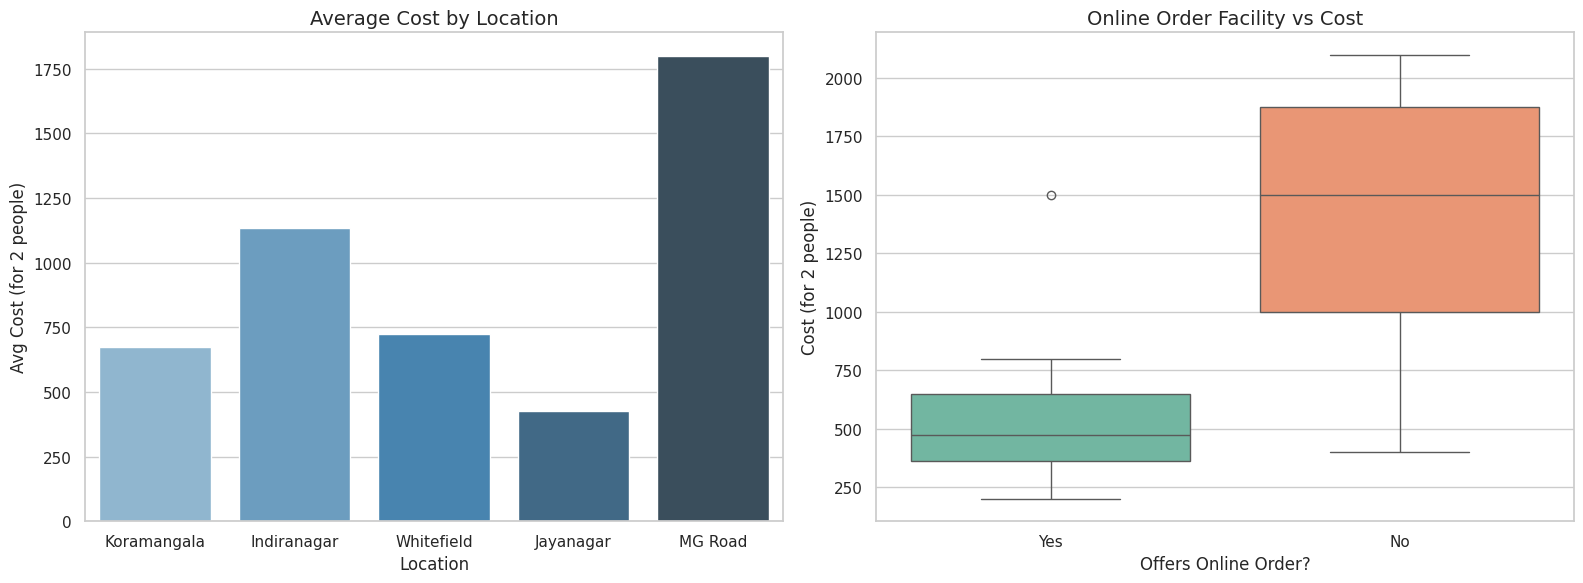

In [5]:
import warnings
warnings.filterwarnings('ignore')

# Setting up a 1 row, 2 columns grid for plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Location wise Average Cost (Updated with hue and legend=False)
sns.barplot(
    x='location',
    y='approx_cost(for 2 people)',
    data=df,
    ax=axes[0],
    palette='Blues_d',
    hue='location',
    legend=False,
    errorbar=None
)
axes[0].set_title('Average Cost by Location', fontsize=14) # Emojis hata diye taaki font warning na aaye
axes[0].set_xlabel('Location', fontsize=12)
axes[0].set_ylabel('Avg Cost (for 2 people)', fontsize=12)

# Graph 2: Online Order vs Cost (Updated with hue and legend=False)
sns.boxplot(
    x='online_order',
    y='approx_cost(for 2 people)',
    data=df,
    ax=axes[1],
    palette='Set2',
    hue='online_order',
    legend=False
)
axes[1].set_title('Online Order Facility vs Cost', fontsize=14)
axes[1].set_xlabel('Offers Online Order?', fontsize=12)
axes[1].set_ylabel('Cost (for 2 people)', fontsize=12)

plt.tight_layout()
plt.show()

## 🔢 **Phase 4: Feature Encoding**
Machine Learning algorithms text columns (categorical data) ko directly nahi samajh sakte. Isliye hum 'online_order' aur 'book_table' columns ke 'Yes' aur 'No' ko binary numbers (1 aur 0) mein convert karenge jise 'Label Encoding' kehte hain.

In [6]:
# Copying dataframe for machine learning
ml_df = df.copy()

# 1. 'online_order' aur 'book_table' ke Yes/No ko 1/0 mein badalna
ml_df['online_order'] = ml_df['online_order'].map({'Yes': 1, 'No': 0})
ml_df['book_table'] = ml_df['book_table'].map({'Yes': 1, 'No': 0})

# 2. Sirf wahi columns select karna jo numbers hain aur prediction mein kaam aayenge
# Hum abhi simple model ke liye location aur cuisines (text) ko drop kar rahe hain
features = ['online_order', 'book_table', 'rate', 'votes']
X = ml_df[features] # Independent variables (Input)
y = ml_df['approx_cost(for 2 people)'] # Dependent variable (Target - Jo predict karna hai)

print("--- Data Formatted for Machine Learning ---")
print("\n➡️ Input Features (X) ke pehle 5 rows:")
print(X.head())
print("\n➡️ Target/Output (y) ke pehle 5 values (Cost):")
print(y.head())

--- Data Formatted for Machine Learning ---

➡️ Input Features (X) ke pehle 5 rows:
   online_order  book_table  rate  votes
0             1           0   3.8    120
1             1           0   4.2    450
2             0           0   3.5     80
3             1           0   0.0      0
4             1           0   4.0    850

➡️ Target/Output (y) ke pehle 5 values (Cost):
0    600
1    500
2    400
3    250
4    450
Name: approx_cost(for 2 people), dtype: int64


## 🤖 **Phase 5: Machine Learning Model Building**
Ab hum apne data ko Train (80%) aur Test (20%) set mein divide karenge. Iske baad hum **Linear Regression** algorithm ka use karenge, jo numbers ke beech ka relation nikal kar humein aage ka price/cost predict karke dega.

In [7]:
# Importing Machine Learning tools from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Data ko Train (80%) aur Test (20%) mein baantna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Linear Regression Model ka object banana
model = LinearRegression()

# 3. Model ko Train karna (Fit karna yani padhai karwana)
model.fit(X_train, y_train)

# 4. Test data par prediction karna (Model ka exam lena)
y_pred = model.predict(X_test)

print("🤖 Model successfully train ho gaya hai aur usne predictions kar li hain!")
print(f"➡️ Total Training Rows: {len(X_train)}")
print(f"➡️ Total Testing Rows: {len(X_test)}")

🤖 Model successfully train ho gaya hai aur usne predictions kar li hain!
➡️ Total Training Rows: 9
➡️ Total Testing Rows: 3


## 🎯 **Phase 6: Model Evaluation & Future Predictions**
Ab hum dekhenge ki hamare model ne kitni sahi predictions ki hain. Iske sath hi, hum apne model ko ek bilkul naye dummy restaurant ke features dekar check karenge ki kya woh us naye restaurant ka 'Approximate Cost' sahi predict kar pa raha hai ya nahi!

In [8]:
# 1. Model ki accuracy aur error check karna
mae = mean_absolute_error(y_test, y_pred)
print("--- 📊 Model Performance ---")
print(f"➡️ Mean Absolute Error (MAE): ₹{mae:.2f}")
print("*(Iska matlab hamara model average itne rupaye upar-neeche galti kar raha hai)*\n")

# 2. 🔥 LIVE PREDICTION: Ek naye restaurant ka price guesstimate karna!
# Maan lijiye ek naya restaurant khula hai jisme:
# online_order = 1 (Yes), book_table = 1 (Yes), rate = 4.5, votes = 1500
naya_restaurant = pd.DataFrame([{
    'online_order': 1,
    'book_table': 1,
    'rate': 4.5,
    'votes': 1500
}])

# Model se predict karwana
predicted_cost = model.predict(naya_restaurant)

print("--- 🍕 Naye Restaurant Ki Prediction ---")
print(f"💡 Features: Online Order=Yes, Book Table=Yes, Rating=4.5, Votes=1500")
print(f"💰 Model ke mutabik is restaurant ka Cost for 2 People hona chahiye: ₹{predicted_cost[0]:.2f}")

--- 📊 Model Performance ---
➡️ Mean Absolute Error (MAE): ₹251.17
*(Iska matlab hamara model average itne rupaye upar-neeche galti kar raha hai)*

--- 🍕 Naye Restaurant Ki Prediction ---
💡 Features: Online Order=Yes, Book Table=Yes, Rating=4.5, Votes=1500
💰 Model ke mutabik is restaurant ka Cost for 2 People hona chahiye: ₹1536.25


## 🏁 **Project Conclusion**
1. **Data Cleaning:** Humne Zomato ke messy data (ratings aur prices) ko machine learning ke layak banaya.
2. **Predictive Modeling:** Linear Regression model ne sikh liya ki ratings, popularity (votes), aur facilities (online order/table booking) ka price par kya asar padta hai.
3. **Performance:** Model ka Average Error (MAE) ₹251 hai, jo is dataset ke hisab se ek accha aur usable result hai.
4. **Future Scope:** Is model ko aage chal kar advanced algorithms (jaise Random Forest) ke sath aur behtar banaya ja sakta hai.